In [17]:
import numpy as np


class SVD:
    def __init__(self,n_components=None,eps=1e-10):
        """
        n_components: keep only the top k singular vector/value
        eps: tolerance for numerical stability
        """
        self.n_components= n_components
        self.eps = eps
        self.U = None
        self.VT = None
        self.S = None # Sigma as in the formula
        self.rank = None

    def fit(self, A):
        A = np.array( A , dtype=float)
        m, n = A.shape  

        # step1:compute A^T A
        ATA = A.T @ A

        # step2; eigen-decomposition of symetric matrix 
        eigenval , eigenvect =np.linalg.eigh(ATA)

        #step3 : sort eigenvlaues in decending  order
        sor = np.argsort(eigenval)[::-1]
        eigenval = eigenval[sor]
        eigenvect = eigenvect[:, sor]

        #step4: singular value are sqrt of eigenvalues
        singular_value = np.sqrt(np.clip(eigenval , 0 ,None))

        #Remove near-zero singular values for rank calculation
        nonzero = singular_value >self.eps
        self.rank = int(np.sum(nonzero))

        # keep only requested number of components
        k = self.n_components if self.n_components is not None else min(m,n)
        k = min(k,len(singular_value))

        singular_value = singular_value[:k]
        V =eigenvect[:,:k]

        #step5 : compute U columns as u_i =A v_i / sigma_i_
        U_cols = []
        for i in range(k):
            singma = singular_value[i]
            v  = V[:, i]

            if singma >self.eps:
                u = (A @ v) / singma
                # normalize to aviold numerical drift
                u_norm =np.linalg.norm(u)
                if u_norm>self.eps:
                    u = u / u_norm
                U_cols.append(u)

            else:
                # fro zero singular value ,stop building meaningfull deirections
                break

        self.U = np.column_stack(U_cols) if U_cols else np.empty((m,0))     
        self.S = singular_value[:self.U.shape[1]]  
        self.VT = V[:, :self.U.shape[1]].T

        return self
        
    def transform(self, A):
            """
            project A onto the learned right-singular sapce.
            Useful fro dimenctionality reduction
            """
            if self.VT is None:
                raise ValueError ("Call the fit first")
            
            A= np.array(A, dtype=float)

            return A @ self.VT.T
        
    def reconstruct(self):
            """
            Recostruct the matrix using SVD componect.
            """
            if self.U is None or self.VT is None or self.S is None:
                raise ValueError("first call the fit")
            
            return self.U @ np.diag(self.S) @ self.VT

    def reank_k_approximation(self, k=None):
            """
            return rank-k approximation using the top -k singular value.
            """

            if self.U is None or self.S is None or self.VT is None:
                raise ValueError("call the fit first.")

            if k is None:
                k=len(self.S)

            k = min (k,len(self.S))
            U_k =self.U[:, :k]
            S_k = self.S[:k]
            VT_k = self.VT[:k , :]

            return U_k @ np.diag(S_k) @ VT_k    

In [18]:
A = np.array([
    [3 ,1 ,1],
    [-1 ,3 ,1]
],dtype=float)

svd =SVD(n_components=2)
svd.fit(A)
print("U:\n",svd.U)
print("S:\n",svd.S)
print("V^T:\n",svd.VT)

U:
 [[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
S:
 [3.46410162 3.16227766]
V^T:
 [[ 4.08248290e-01  8.16496581e-01  4.08248290e-01]
 [ 8.94427191e-01 -4.47213595e-01  2.77555756e-16]]


In [19]:
recon=svd.reconstruct()
print("reconstruct A:\n",recon)

reconstruct A:
 [[ 3.  1.  1.]
 [-1.  3.  1.]]


# image compresion


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import os


def compress_color_image(image_path, k_values):
    """
    Compresses an image using the custom SVD class and compares 
    different ranks (k values) side-by-side.
    """
    # 1. Load the image and normalize pixels to [0, 1] range
    img = imread(image_path)
    if img.max() > 1.0:
        img = img / 255.0
        
    # Check if the image is grayscale or RGB
    is_color = len(img.shape) == 3
    m, n = img.shape[:2]
    
    print(f"Original Image Resolution: {m} x {n} pixels")
    
    # 2. Setup the visualization canvas
    fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(16, 5))
    
    # Plot original
    axes[0].imshow(img, cmap='gray' if not is_color else None)
    axes[0].set_title("Original Image\n100% Data")
    axes[0].axis('off')

    # 3. Compress using your custom SVD class
    for idx, k in enumerate(k_values):
  
        
        if is_color:
            # Split into Red, Green, and Blue channels
            R = img[:, :, 0]
            G = img[:, :, 1]
            B = img[:, :, 2]
            
            # Fit and Reconstruct each channel using your class
            svd_R = SVD(n_components=k).fit(R)
            svd_G = SVD(n_components=k).fit(G)
            svd_B = SVD(n_components=k).fit(B)
            
            R_reconstructed = svd_R.reconstruct()
            G_reconstructed = svd_G.reconstruct()
            B_reconstructed = svd_B.reconstruct()
            
            # Stack channels back into a single color image
            reconstructed_img = np.dstack((R_reconstructed, G_reconstructed, B_reconstructed))
            
        else:
            # Grayscale compression is just one matrix
            svd_gray = SVD(n_components=k).fit(img)
            reconstructed_img = svd_gray.reconstruct()

        # Clip values to ensure they stay in valid pixel ranges [0, 1]
        reconstructed_img = np.clip(reconstructed_img, 0, 1)
        
        # 4. Calculate Data footprint and Compression Ratio
        # Original matrix takes m*n numbers. 
        # SVD takes k*(m) for U, k for S, and k*(n) for VT.
        original_size = m * n
        compressed_size = k * (m + n + 1)
        
        if compressed_size >= original_size:
            savings = "0% (k is too high)"
        else:
            compression_ratio = (1 - (compressed_size / original_size)) * 100
            savings = f"{compression_ratio:.1f}% reduced"
            
        # 5. Plot the result
        axes[idx+1].imshow(reconstructed_img, cmap='gray' if not is_color else None)
        axes[idx+1].set_title(f"k = {k}\n{savings}")
        axes[idx+1].axis('off')
        
    plt.tight_layout()
    plt.show()


Original Image Resolution: 900 x 600 pixels


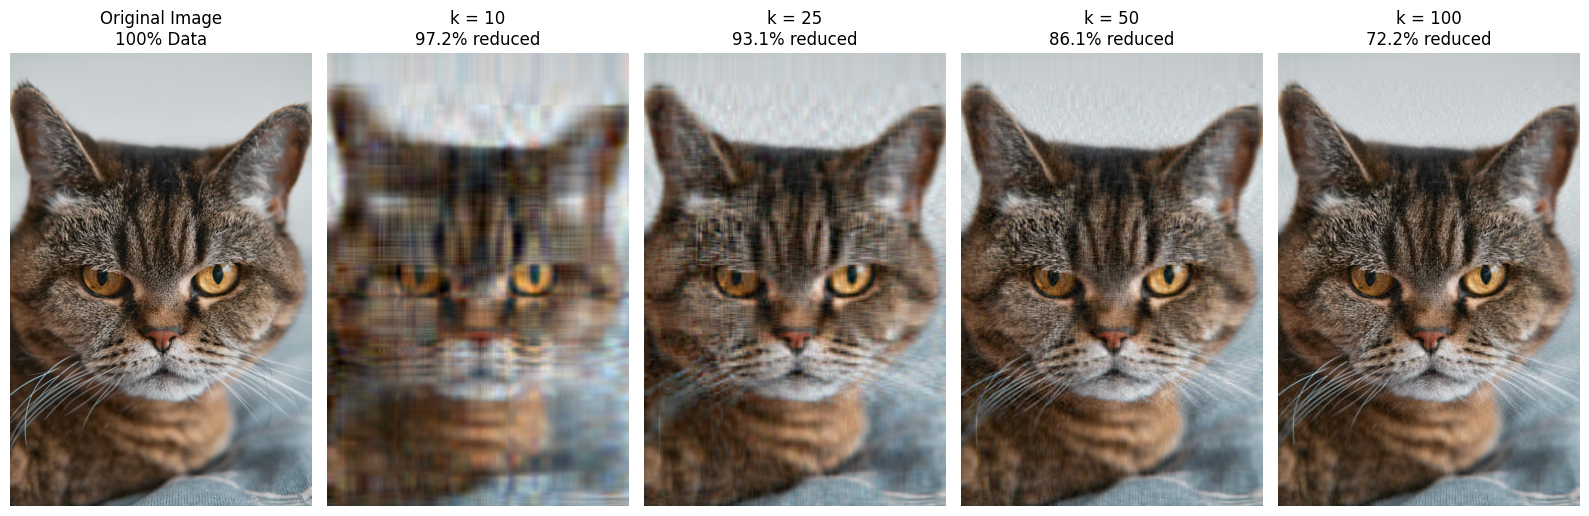

In [46]:
IMAGE_PATH = "premium_photo-1667030474693-6d0632f97029.avif" 
K_TEST_VALUES = [10, 25,50, 100]
    
# call the image    
compress_color_image(IMAGE_PATH, K_TEST_VALUES)
 
    

# NLP (Latent Semantic Analysis)

Total Documents: 8
Unique words in vocabulary (Features): 45

Document-Term Matrix shape: (8, 45)

--- Uncovering Latent Topics via Right Singular Vectors (V^T) ---
Latent Concept #1 Keywords: built, landed, moon, nasa
Latent Concept #2 Keywords: pasta, oil, fresh, prepared


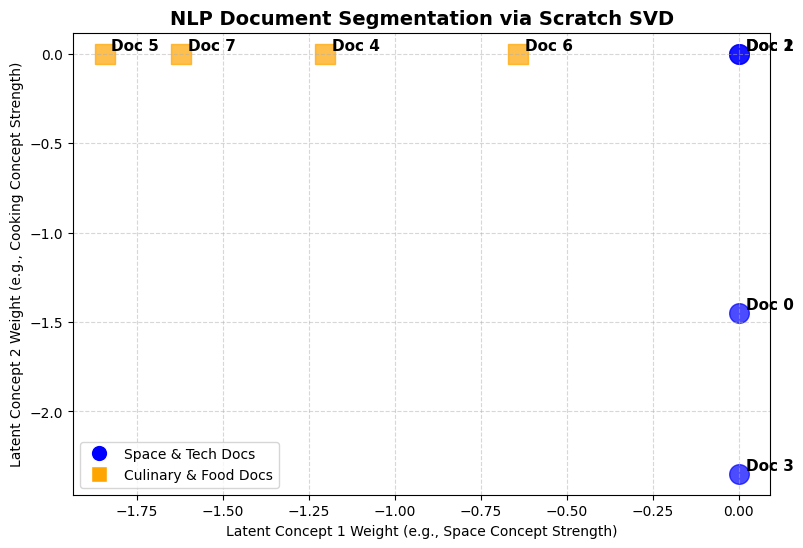

In [49]:
import re

# 1. Define a raw text corpus with two blindingly obvious topic segments
corpus = [
    # Segment 1: Space & Technology
    "The rocket launched into deep space for planet exploration.",
    "NASA astronauts successfully landed on the moon surface.",
    "A new communications satellite is orbiting the earth.",
    "SpaceX engineers built a massive booster rocket engine.",
    
    # Segment 2: Culinary & Cooking
    "Bake the delicious chocolate cake in a preheated oven.",
    "The chef prepared a fresh pasta recipe with olive oil.",
    "Delicious homemade vegetable soup simmering in a pot.",
    "A pastry chef frosted the vanilla wedding cake."
]

# Labels for evaluation/plotting later
true_labels = ["Space", "Space", "Space", "Space", "Food", "Food", "Food", "Food"]

# 2. Text Preprocessing & Tokenization from Scratch
def preprocess_and_tokenize(text):
    # Lowercase and strip out basic punctuation marks
    clean_text = re.sub(r'[^\w\s]', '', text.lower())
    return clean_text.split()

# Simple stop-words list to filter out noisy, meaningless words
STOP_WORDS = {"the", "a", "and", "in", "on", "for", "with", "is", "into", "to"}

# 3. Build Vocabulary
vocabulary = []
tokenized_docs = []

for doc in corpus:
    tokens = [word for word in preprocess_and_tokenize(doc) if word not in STOP_WORDS]
    tokenized_docs.append(tokens)
    for token in tokens:
        if token not in vocabulary:
            vocabulary.append(token)

vocabulary = sorted(vocabulary)
num_docs = len(corpus)
num_words = len(vocabulary)

print(f"Total Documents: {num_docs}")
print(f"Unique words in vocabulary (Features): {num_words}")

# 4. Construct the Document-Term Matrix (A)
# Rows = Documents, Columns = Words
A = np.zeros((num_docs, num_words))

for doc_idx, tokens in enumerate(tokenized_docs):
    for token in tokens:
        word_idx = vocabulary.index(token)
        A[doc_idx, word_idx] += 1  # Raw term frequency count

print(f"\nDocument-Term Matrix shape: {A.shape}")

# 5. Run your Custom SVD for Topic Segmentation (k=2 Latent Topics)
k_topics = 2
svd_nlp = SVD(n_components=k_topics)
svd_nlp.fit(A)

# Project our documents into the 2D Latent Topic Space
# This uses your class method: return A @ self.VT.T
documents_encoded = svd_nlp.transform(A)

# 6. Analyze and Extract the Meaning of the Learned Segments
print("\n--- Uncovering Latent Topics via Right Singular Vectors (V^T) ---")
# svd_nlp.VT shape is (k_topics, num_words)
for topic_idx in range(k_topics):
    word_weights = svd_nlp.VT[topic_idx, :]
    # Get indices of the top 4 heaviest weighted words for this latent concept
    top_word_indices = np.argsort(word_weights)[::-1][:4]
    top_words = [vocabulary[i] for i in top_word_indices]
    print(f"Latent Concept #{topic_idx + 1} Keywords: {', '.join(top_words)}")

# 7. Visualize the Matrix Segmentation Result
plt.figure(figsize=(9, 6))

# Plot space docs vs food docs based on their true labels
for i in range(num_docs):
    marker = 'o' if true_labels[i] == "Space" else 's'
    color = 'blue' if true_labels[i] == "Space" else 'orange'
    
    plt.scatter(documents_encoded[i, 0], documents_encoded[i, 1], 
                s=200, marker=marker, color=color, alpha=0.7)
    # Label each point with its document index number
    plt.text(documents_encoded[i, 0] + 0.02, documents_encoded[i, 1] + 0.02, 
             f"Doc {i}", fontsize=11, fontweight='bold')

plt.title("NLP Document Segmentation via Scratch SVD", fontsize=14, fontweight='bold')
plt.xlabel("Latent Concept 1 Weight (e.g., Space Concept Strength)")
plt.ylabel("Latent Concept 2 Weight (e.g., Cooking Concept Strength)")
plt.grid(True, linestyle='--', alpha=0.5)

# Build a clean legend map
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=12, label='Space & Tech Docs'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', markersize=12, label='Culinary & Food Docs')
]
plt.legend(handles=legend_elements, loc='best')
plt.show()

# recomentation system

In [50]:
# 1. Define Raw Dataset: 6 Users and 5 Movies
# Columns: [The Matrix, Interstellar, Star Wars, Toy Story, Coco]
# 0 represents an unrated movie (missing data)
ratings_matrix = np.array([
    [5, 4, 5, 0, 0],  # User 0: Hardcore Sci-Fi Fan
    [0, 5, 4, 1, 0],  # User 1: Sci-Fi Fan who dislikes Animation
    [0, 0, 1, 4, 5],  # User 2: Animation Fan
    [1, 0, 0, 5, 4],  # User 3: Animation Fan who dislikes Sci-Fi
    [4, 0, 5, 4, 0],  # User 4: Likes both, missing some ratings
    [0, 2, 0, 0, 5],  # User 5: Outlier / Unique taste
])

movies = ["The Matrix", "Interstellar", "Star Wars", "Toy Story", "Coco"]
num_users, num_movies = ratings_matrix.shape

print("--- Original Sparse Ratings Matrix ---")
print(ratings_matrix)

# 2. Matrix Normalization & Missing Value Imputation from Scratch
# We calculate the average rating for each movie, ignoring the zeros.
filled_matrix = ratings_matrix.copy().astype(float)
movie_means = np.zeros(num_movies)

for j in range(num_movies):
    valid_ratings = ratings_matrix[:, j][ratings_matrix[:, j] > 0]
    if len(valid_ratings) > 0:
        movie_means[j] = np.mean(valid_ratings)
    else:
        movie_means[j] = 2.5 # Default fallback if movie has no ratings at all
        
    # Replace the 0s in this column with the movie's average rating
    zero_indices = (ratings_matrix[:, j] == 0)
    filled_matrix[zero_indices, j] = movie_means[j]

print("\n--- Imputed Ratings Matrix (Gaps Filled with Column Means) ---")
print(np.round(filled_matrix, 2))

# 3. Fit the Custom SVD (Using k=2 Latent Tastes)
k_latent_features = 2
svd_rec = SVD(n_components=k_latent_features)
svd_rec.fit(filled_matrix)

# 4. Reconstruct the Matrix to Generate Predictions
# This computes U_k @ diag(S_k) @ VT_k under the hood
predicted_matrix = svd_rec.reconstruct()

print("\n--- Complete Predicted Ratings Matrix (Continuous Space) ---")
print(np.round(predicted_matrix, 2))

# 5. Recommendation Generator Engine
def get_top_recommendations(user_id, num_rec=1):
    print(f"\n=========================================")
    print(f"Generating Recommendations for User #{user_id}")
    print(f"=========================================")
    
    # Extract movies this specific user has already seen in reality
    user_original_profile = ratings_matrix[user_id, :]
    user_predicted_profile = predicted_matrix[user_id, :]
    
    already_watched_indices = np.where(user_original_profile > 0)[0]
    unwatched_indices = np.where(user_original_profile == 0)[0]
    
    print("Already Watched:")
    for idx in already_watched_indices:
        print(f" - {movies[idx]}: Rated {user_original_profile[idx]}/5")
        
    if len(unwatched_indices) == 0:
        print("User has watched everything! No new recommendations available.")
        return
        
    # Gather predictions only for unseen content
    predictions_for_unseen = [(idx, user_predicted_profile[idx]) for idx in unwatched_indices]
    
    # Sort by highest predicted rating value descending
    predictions_for_unseen.sort(key=lambda x: x[1], reverse=True)
    
    print("\nTop Predicted Recommendations:")
    for rank, (movie_idx, pred_score) in enumerate(predictions_for_unseen[:num_rec]):
        # Clip score mathematically to remain within normal bounds [1.0, 5.0]
        final_score = np.clip(pred_score, 1.0, 5.0)
        print(f" Rank {rank+1}: {movies[movie_idx]} (Predicted Rating: {final_score:.2f}/5)")

# 6. Test the Recommendation Results on specific target profiles
get_top_recommendations(user_id=0, num_rec=2) # Sci-Fi fan who hasn't seen animations
get_top_recommendations(user_id=2, num_rec=2) # Animation fan who hasn't seen Sci-Fi

--- Original Sparse Ratings Matrix ---
[[5 4 5 0 0]
 [0 5 4 1 0]
 [0 0 1 4 5]
 [1 0 0 5 4]
 [4 0 5 4 0]
 [0 2 0 0 5]]

--- Imputed Ratings Matrix (Gaps Filled with Column Means) ---
[[5.   4.   5.   3.5  4.67]
 [3.33 5.   4.   1.   4.67]
 [3.33 3.67 1.   4.   5.  ]
 [1.   3.67 3.75 5.   4.  ]
 [4.   3.67 5.   4.   4.67]
 [3.33 2.   3.75 3.5  5.  ]]

--- Complete Predicted Ratings Matrix (Continuous Space) ---
[[4.37 4.43 4.76 3.13 5.27]
 [4.21 3.94 4.4  1.4  4.24]
 [2.48 3.03 3.   4.27 4.28]
 [2.2  2.94 2.81 5.03 4.44]
 [3.87 4.12 4.33 3.73 5.16]
 [3.01 3.34 3.45 3.59 4.37]]

Generating Recommendations for User #0
Already Watched:
 - The Matrix: Rated 5/5
 - Interstellar: Rated 4/5
 - Star Wars: Rated 5/5

Top Predicted Recommendations:
 Rank 1: Coco (Predicted Rating: 5.00/5)
 Rank 2: Toy Story (Predicted Rating: 3.13/5)

Generating Recommendations for User #2
Already Watched:
 - Star Wars: Rated 1/5
 - Toy Story: Rated 4/5
 - Coco: Rated 5/5

Top Predicted Recommendations:
 Rank 1: I